In [2]:
!pip install monai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.0 MB/s eta 0:00:0031m17.4 MB/s eta 0:00:01


In [26]:
import monai.metrics
from monai.metrics import MeanIoU, compute_generalized_dice, compute_meaniou

In [5]:
import torch
import torch.nn as nn
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Mid-level
        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0)  # Adjusted output_padding
        )

    def forward(self, x):
        # Encoder
        x1 = self.encoder(x)

        # Mid-level
        x2 = self.mid_level(x1)

        # Decoder
        x3 = self.decoder(x2)

        return x3

# Example usage:
in_channels = 1  # Assuming grayscale images
out_channels = 1  # Assuming binary segmentation output

# Adjust the model instantiation
model = UNet(in_channels, out_channels)


In [7]:
model.load_state_dict(torch.load('/localhome/asa420/unet_model.pth'))

<All keys matched successfully>

In [21]:
from skimage.morphology import erosion
from skimage import restoration
import imageio

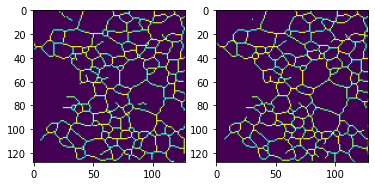

In [117]:

# from plantcv import plantcv as pcv
from skimage.morphology import skeletonize

image_path = f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/images/atl1_er_mean.png'

image = Image.open(image_path)
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image)

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)
type(output_probs)

# Convert tensors to numpy arrays for visualization
image_np = image.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())
norm_er = erosion(norm)
rb = restoration.rolling_ball(norm)

rb2 = restoration.rolling_ball(norm_er)

subt = norm - rb

subt[subt < 0.1] = 0.
subt[subt >= 0.1] = 255.

subt2 = norm_er - rb2
subt2[subt2 < 0.1] = 0.
subt2[subt2 >= 0.1] = 255.


plt.subplot(121)
sk = skeletonize(subt / 255.)
plt.imshow(sk)

plt.subplot(122)
sk2 = skeletonize(subt2 / 255.)
plt.imshow(sk2)

In [110]:

# groups = {'ATL':('A', 26), 'Climp':('C', 31), 'Control':('Ct', 31), 'RTN':('R', 29)}


def get_unet_skel(groups):
    for group, (prefix, seq_len) in groups.items():
        for seq in range(1, seq_len+1):
            image_path = f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/images/{group.lower()}{seq}_er_mean.png'

            image = Image.open(image_path)
            transform = transforms.Compose([
            #     transforms.Resize((128, 128)),
                transforms.ToTensor(),
            ])

            image = transform(image)
            image = image.unsqueeze(0)  # Add batch dimension

            # Forward pass through the model
            model.eval()
            with torch.no_grad():
                output = model(image)

            # Convert the output to probabilities by applying the sigmoid activation
            output_probs = torch.sigmoid(output)
            type(output_probs)

            # Convert tensors to numpy arrays for visualization
            image_np = image.squeeze().numpy()
            output_probs_np = output_probs.cpu().squeeze().numpy()

            norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())
#             norm_er = erosion(norm)
            rb = restoration.rolling_ball(norm)

#             subt = norm_er - rb
            subt = norm - rb

            subt[subt < 0.1] = 0.
            subt[subt >= 0.1] = 255.
            
#             plt.imshow(subt)
            
            imageio.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/predictions/{group.lower()}{seq}_er_mean_pred.png', subt)


In [ ]:
groups = {'atl':('A', 26), 'climp':('C', 31), 'control':('Ct', 31), 'rtn':('R', 29)}

get_unet_skel(groups)

In [29]:
gt = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/masks/atl1_er_mean_mask.png')
pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/masks/atl1_er_mean_mask.png')

m = MeanIoU()
# m = compute_meaniou(pred, gt)

In [ ]:
# !pip install miseval

In [32]:
from miseval import evaluate

In [82]:
from skimage import color
import matplotlib.pyplot as plt

import numpy as np
from skimage.filters import threshold_otsu, threshold_local, threshold_multiotsu
import imageio

def get_analyzer_bin(group):
    for i in range(1, 30):
        analyzer_enh = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/{group}/ER_{group}{i}.png')
        op = analyzer_enh[:,:,0]

        thr = threshold_otsu(op)

        out = op > thr
        out = out.astype('uint8') * 255
        imageio.imsave(f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/{group}/ER_{group}{i}_bin.png', out)
        # plt.imshow(out.astype('float'))

get_analyzer_bin('rtn')

In [87]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/atl/ER_atl1_bin.png')

In [88]:
img.shape

(1709, 1709)

In [93]:
from PIL import Image

def get_analyzer_bin_res(group):
    for i in range(1, 30):
        img = Image.open(f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/{group}/ER_{group}{i}_bin.png')

        # Resize using Lanczos interpolation
        resized_img = img.resize((128, 128), Image.LANCZOS)

        # Save or display the resized image
        resized_img.save(f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/{group}/ER_{group}{i}_bin_res.png')

get_analyzer_bin_res('rtn')

/tmp/ipykernel_595805/1306432816.py:8: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  resized_img = img.resize((128, 128), Image.LANCZOS)


In [ ]:
def get_erv2_bin():
    img = imageio.imread('')
    img[img >= 85] = 255
    imageio.imsave('')

In [118]:
import numpy as np

def intersection_over_union(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    union = np.logical_or(pred_mask, true_mask)
    iou = np.sum(intersection) / np.sum(union)
    return iou

def pixel_accuracy(pred_mask, true_mask):
    correct_pixels = np.sum(pred_mask == true_mask)
    total_pixels = pred_mask.size
    accuracy = correct_pixels / total_pixels
    return accuracy

def dice_coefficient(pred_mask, true_mask):
    intersection = np.sum(pred_mask * true_mask)
    dice = (2.0 * intersection) / (np.sum(pred_mask) + np.sum(true_mask))
    return dice



In [133]:
def get_segmentation_scores():
    gt = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/masks/atl5_er_mean_mask.png')

    analyzer_pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/atl/ER_atl5_bin_res.png')
    ernet_pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/ernet_masks/atl/atl5_er_mean_out.png')
#     erv2_pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/erv2_masks/atl/atl5_er_mean_bin.jpg')
    erv2_pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/erv2_new_masks/atl/atl5_er_mean_out_bin.png')
    nerdy_pred = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/predictions/atl5_er_mean_pred.png')

    a_iou = intersection_over_union(analyzer_pred.flatten(), gt.flatten())
    ernet_iou = intersection_over_union(ernet_pred.flatten(), gt.flatten())
    erv2_iou = intersection_over_union(erv2_pred.flatten(), gt.flatten())
    nerdy_iou = intersection_over_union(nerdy_pred.flatten(), gt.flatten())
    
#     a_iou = pixel_accuracy(analyzer_pred.flatten(), gt.flatten())
#     ernet_iou = pixel_accuracy(ernet_pred.flatten(), gt.flatten())
#     erv2_iou = pixel_accuracy(erv2_pred.flatten(), gt.flatten())
#     nerdy_iou = pixel_accuracy(nerdy_pred.flatten(), gt.flatten())
    
#     a_iou = dice_coefficient(analyzer_pred.flatten(), gt.flatten())
#     ernet_iou = dice_coefficient(ernet_pred.flatten(), gt.flatten())
#     erv2_iou = dice_coefficient(erv2_pred.flatten(), gt.flatten())
#     nerdy_iou = dice_coefficient(nerdy_pred.flatten(), gt.flatten())
    
    return [a_iou, ernet_iou, erv2_iou, nerdy_iou]

l = get_segmentation_scores()

In [134]:
l

[0.5155197305101059,
 0.6881527415143603,
 0.5770196425934131,
 0.8424529900050821]